In [1]:
import pandas as pd

In [2]:
!pip install pybaseball

In [3]:
from pybaseball import standings

data_2025 = standings(2025)
data_2025

[                  Tm   W   L  W-L%    GB
 1  Toronto Blue Jays  94  68  .580    --
 2   New York Yankees  94  68  .580    --
 3     Boston Red Sox  89  73  .549   5.0
 4     Tampa Bay Rays  77  85  .475  17.0
 5  Baltimore Orioles  75  87  .463  19.0,
                     Tm   W    L  W-L%    GB
 1  Cleveland Guardians  88   74  .543    --
 2       Detroit Tigers  87   75  .537   1.0
 3   Kansas City Royals  82   80  .506   6.0
 4      Minnesota Twins  70   92  .432  18.0
 5    Chicago White Sox  60  102  .370  28.0,
                    Tm   W   L  W-L%    GB
 1    Seattle Mariners  90  72  .556    --
 2      Houston Astros  87  75  .537   3.0
 3       Texas Rangers  81  81  .500   9.0
 4           Athletics  76  86  .469  14.0
 5  Los Angeles Angels  72  90  .444  18.0,
                       Tm   W   L  W-L%    GB
 1  Philadelphia Phillies  96  66  .593    --
 2          New York Mets  83  79  .512  13.0
 3          Miami Marlins  79  83  .488  17.0
 4         Atlanta Braves  76  86

In [4]:
print(type(data_2025))
print(len(data_2025))

<class 'list'>
6


In [5]:
data_2025[0]

,Tm,W,L,W-L%,GB
1,Toronto Blue Jays,94,68,.580,--
2,New York Yankees,94,68,.580,--
3,Boston Red Sox,89,73,.549,5.0
4,Tampa Bay Rays,77,85,.475,17.0
5,Baltimore Orioles,75,87,.463,19.0


In [6]:
all_teams = pd.concat(data_2025, ignore_index=True)
all_teams

,Tm,W,L,W-L%,GB
0,Toronto Blue Jays,94,68,.580,--
1,New York Yankees,94,68,.580,--
2,Boston Red Sox,89,73,.549,5.0
3,Tampa Bay Rays,77,85,.475,17.0
4,Baltimore Orioles,75,87,.463,19.0
5,Cleveland Guardians,88,74,.543,--
6,Detroit Tigers,87,75,.537,1.0
7,Kansas City Royals,82,80,.506,6.0
8,Minnesota Twins,70,92,.432,18.0
9,Chicago White Sox,60,102,.370,28.0


In [7]:
print(all_teams.shape)
print(all_teams.columns)
all_teams.head()

(30, 5)
Index(['Tm', 'W', 'L', 'W-L%', 'GB'], dtype='object')


,Tm,W,L,W-L%,GB
0,Toronto Blue Jays,94,68,.580,--
1,New York Yankees,94,68,.580,--
2,Boston Red Sox,89,73,.549,5.0
3,Tampa Bay Rays,77,85,.475,17.0
4,Baltimore Orioles,75,87,.463,19.0


In [8]:
url = "https://www.baseball-reference.com/leagues/MLB/2025-standard-batting.shtml"
tables = pd.read_html(url)
print(len(tables))
tables[0].head()

3


,Tm,#Bat,BatAge,R/G,G,PA,AB,R,H,2B,...,SLG,OPS,OPS+,TB,GDP,HBP,SH,SF,IBB,LOB
0,Arizona Diamondbacks,65,27.8,4.88,162,6210,5480,791,1377,277,...,.433,.757,110,2372,109,81,37,64,21,1112
1,Athletics,58,26.1,4.52,162,6151,5547,733,1403,296,...,.431,.749,104,2388,117,44,18,35,14,1106
2,Atlanta Braves,71,28.3,4.47,162,6186,5508,724,1349,243,...,.399,.720,101,2200,98,51,15,36,14,1160
3,Baltimore Orioles,70,26.5,4.18,162,6020,5416,677,1273,251,...,.394,.699,97,2135,102,75,4,41,14,1044
4,Boston Red Sox,56,27.6,4.85,162,6206,5562,786,1414,324,...,.421,.745,106,2344,99,72,13,41,24,1125


In [9]:
batting_2025 = tables[0]
print(batting_2025.columns.tolist())

['Tm', '#Bat', 'BatAge', 'R/G', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'OPS+', 'TB', 'GDP', 'HBP', 'SH', 'SF', 'IBB', 'LOB']


In [10]:
url_pitching = "https://www.baseball-reference.com/leagues/MLB/2025-standard-pitching.shtml"
tables_pitching = pd.read_html(url_pitching)
print(len(tables_pitching))

pitching_2025 = tables_pitching[0]
print(pitching_2025.columns.tolist())

3
['Tm', '#P', 'PAge', 'RA/G', 'W', 'L', 'W-L%', 'ERA', 'G', 'GS', 'GF', 'CG', 'tSho', 'cSho', 'SV', 'IP', 'H', 'R', 'ER', 'HR', 'BB', 'IBB', 'SO', 'HBP', 'BK', 'WP', 'BF', 'ERA+', 'FIP', 'WHIP', 'H9', 'HR9', 'BB9', 'SO9', 'SO/W', 'LOB']


In [11]:
batting_2025 = batting_2025.rename(columns={"R": "R_scored"})
pitching_2025 = pitching_2025.rename(columns={"R": "R_allowed"})

print(batting_2025.columns.tolist())
print(pitching_2025.columns.tolist())

['Tm', '#Bat', 'BatAge', 'R/G', 'G', 'PA', 'AB', 'R_scored', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'OPS+', 'TB', 'GDP', 'HBP', 'SH', 'SF', 'IBB', 'LOB']
['Tm', '#P', 'PAge', 'RA/G', 'W', 'L', 'W-L%', 'ERA', 'G', 'GS', 'GF', 'CG', 'tSho', 'cSho', 'SV', 'IP', 'H', 'R_allowed', 'ER', 'HR', 'BB', 'IBB', 'SO', 'HBP', 'BK', 'WP', 'BF', 'ERA+', 'FIP', 'WHIP', 'H9', 'HR9', 'BB9', 'SO9', 'SO/W', 'LOB']


In [12]:
team_stats = pd.merge(batting_2025, pitching_2025, on="Tm", suffixes=("_bat", "_pitch"))
print(team_stats.shape)
team_stats.head()

(33, 64)


,Tm,#Bat,BatAge,R/G,G_bat,PA,AB,R_scored,H_bat,2B,...,BF,ERA+,FIP,WHIP,H9,HR9,BB9,SO9,SO/W,LOB_pitch
0,Arizona Diamondbacks,65,27.8,4.88,162,6210,5480,791,1377,277,...,6183,94,4.27,1.318,8.7,1.2,3.1,8.0,2.58,1093
1,Athletics,58,26.1,4.52,162,6151,5547,733,1403,296,...,6232,92,4.66,1.361,8.7,1.4,3.6,8.3,2.32,1120
2,Atlanta Braves,71,28.3,4.47,162,6186,5508,724,1349,243,...,6116,97,4.20,1.306,8.4,1.2,3.3,8.9,2.67,1088
3,Baltimore Orioles,70,26.5,4.18,162,6020,5416,677,1273,251,...,6166,87,4.41,1.365,9.0,1.4,3.3,8.5,2.58,1098
4,Boston Red Sox,56,27.6,4.85,162,6206,5562,786,1414,324,...,6150,112,3.98,1.286,8.3,1.0,3.3,8.5,2.57,1156


In [13]:
print(team_stats["Tm"].tolist())

['Arizona Diamondbacks', 'Athletics', 'Atlanta Braves', 'Baltimore Orioles', 'Boston Red Sox', 'Chicago Cubs', 'Chicago White Sox', 'Cincinnati Reds', 'Cleveland Guardians', 'Colorado Rockies', 'Detroit Tigers', 'Houston Astros', 'Kansas City Royals', 'Los Angeles Angels', 'Los Angeles Dodgers', 'Miami Marlins', 'Milwaukee Brewers', 'Minnesota Twins', 'New York Mets', 'New York Yankees', 'Philadelphia Phillies', 'Pittsburgh Pirates', 'San Diego Padres', 'Seattle Mariners', 'San Francisco Giants', 'St. Louis Cardinals', 'Tampa Bay Rays', 'Texas Rangers', 'Toronto Blue Jays', 'Washington Nationals', 'League Average', 'Tm', nan]


In [14]:
team_stats = team_stats[team_stats["Tm"].notna()]
team_stats = team_stats[team_stats["Tm"] != "League Average"]
team_stats = team_stats[team_stats["Tm"] != "Tm"]

print(team_stats.shape)

(30, 64)


In [15]:
print(team_stats["Tm"].duplicated().sum())
print(team_stats.isna().sum().sum())

0
0


In [16]:
print(team_stats["R_scored"].dtype)
print(team_stats["R_allowed"].dtype)

object
object


In [17]:
team_stats["R_scored"] = pd.to_numeric(team_stats["R_scored"])
team_stats["R_allowed"] = pd.to_numeric(team_stats["R_allowed"])

print(team_stats["R_scored"].dtype)
print(team_stats["R_allowed"].dtype)

int64
int64


In [18]:
team_stats["run_diff"] = team_stats["R_scored"] - team_stats["R_allowed"]
team_stats[["Tm", "R_scored", "R_allowed", "run_diff"]].sort_values("run_diff", ascending=False)

,Tm,R_scored,R_allowed,run_diff
16,Milwaukee Brewers,806,634,172
19,New York Yankees,849,685,164
5,Chicago Cubs,793,649,144
14,Los Angeles Dodgers,825,683,142
20,Philadelphia Phillies,778,648,130
4,Boston Red Sox,786,676,110
22,San Diego Padres,702,621,81
27,Texas Rangers,684,605,79
28,Toronto Blue Jays,798,721,77
23,Seattle Mariners,766,694,72


In [19]:
print(team_stats["OPS"].dtype)
team_stats[["Tm", "OPS", "run_diff"]].sort_values("OPS", ascending=False).head(10)

object


,Tm,OPS,run_diff
19,New York Yankees,.787,164
14,Los Angeles Dodgers,.768,142
28,Toronto Blue Jays,.761,77
20,Philadelphia Phillies,.759,130
0,Arizona Diamondbacks,.757,6
18,New York Mets,.753,51
5,Chicago Cubs,.751,144
1,Athletics,.749,-84
4,Boston Red Sox,.745,110
23,Seattle Mariners,.740,72


In [20]:
team_stats["OPS"] = pd.to_numeric(team_stats["OPS"])
print(team_stats["OPS"].dtype)

float64


In [21]:
print(team_stats.dtypes)

Tm           object
#Bat         object
BatAge       object
R/G          object
G_bat        object
              ...  
BB9          object
SO9          object
SO/W         object
LOB_pitch    object
run_diff      int64
Length: 65, dtype: object


In [22]:
print(team_stats[["R_scored", "R_allowed", "OPS"]].dtypes)

R_scored       int64
R_allowed      int64
OPS          float64
dtype: object


In [23]:
team_stats["W"] = pd.to_numeric(team_stats["W"])

correlation_check = team_stats[["W", "run_diff", "OPS"]].corr()
correlation_check

,W,run_diff,OPS
W,1.000000,0.927077,0.642299
run_diff,0.927077,1.000000,0.618988
OPS,0.642299,0.618988,1.000000


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

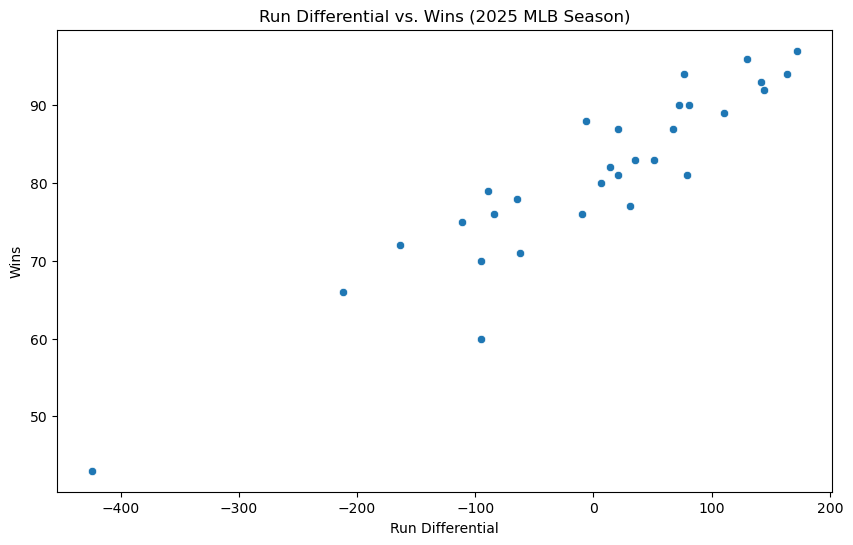

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=team_stats, x="run_diff", y="W")
plt.title("Run Differential vs. Wins (2025 MLB Season)")
plt.xlabel("Run Differential")
plt.ylabel("Wins")
plt.show()

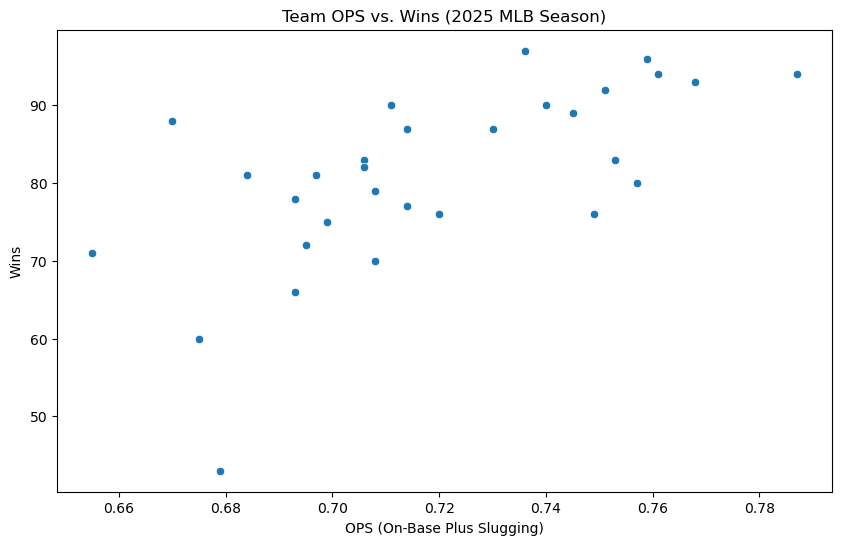

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=team_stats, x="OPS", y="W")
plt.title("Team OPS vs. Wins (2025 MLB Season)")
plt.xlabel("OPS (On-Base Plus Slugging)")
plt.ylabel("Wins")
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X = team_stats[["run_diff"]]
y = team_stats["W"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(24, 1)
(6, 1)


In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(model.intercept_)
print(model.coef_)

80.81078741351165
[0.08540195]


In [29]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("MAE:", mae)

R²: 0.8963618421907917
MAE: 4.564564591225573


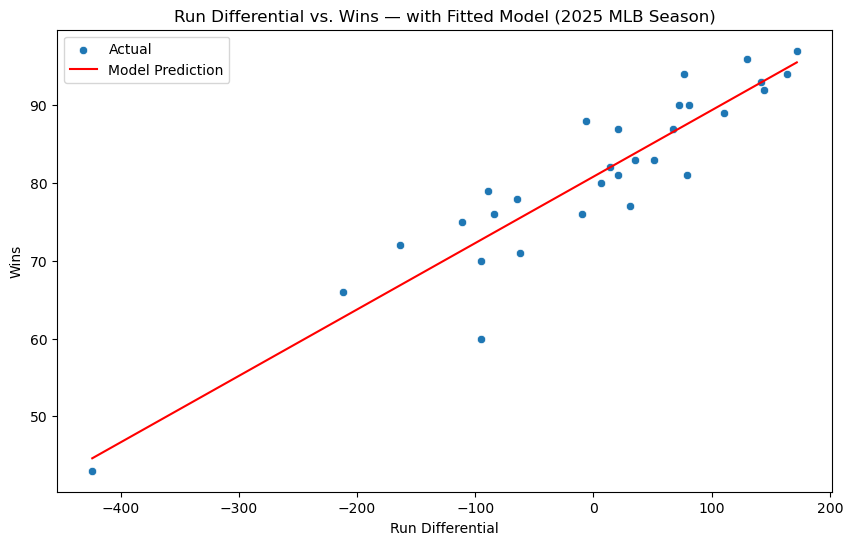

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=team_stats, x="run_diff", y="W", label="Actual")
sns.lineplot(x=team_stats["run_diff"], y=model.predict(team_stats[["run_diff"]]), color="red", label="Model Prediction")
plt.title("Run Differential vs. Wins — with Fitted Model (2025 MLB Season)")
plt.xlabel("Run Differential")
plt.ylabel("Wins")
plt.legend()
plt.show()

In [31]:
print(team_stats.shape)
print(model.intercept_)




(30, 65)
80.81078741351165


In [32]:
team_stats["predicted_W"] = model.predict(team_stats[["run_diff"]])
team_stats["residual"] = team_stats["W"] - team_stats["predicted_W"]

team_stats[["Tm", "W", "predicted_W", "residual"]].sort_values("residual", ascending=False)

,Tm,W,predicted_W,residual
8,Cleveland Guardians,88,80.298376,7.701624
28,Toronto Blue Jays,94,87.386737,6.613263
15,Miami Marlins,79,73.210014,5.789986
13,Los Angeles Angels,72,66.804868,5.195132
11,Houston Astros,87,82.604228,4.395772
20,Philadelphia Phillies,96,91.913041,4.086959
3,Baltimore Orioles,75,71.331171,3.668829
29,Washington Nationals,66,62.705574,3.294426
23,Seattle Mariners,90,86.959728,3.040272
25,St. Louis Cardinals,78,75.259661,2.740339


In [33]:
X_multi = team_stats[["run_diff", "OPS"]]
y_multi = team_stats["W"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

print(model_multi.intercept_)
print(model_multi.coef_)

34.53511085040979
[ 0.07135843 64.29828404]


In [34]:
y_pred_multi = model_multi.predict(X_test_m)

r2_multi = r2_score(y_test_m, y_pred_multi)
mae_multi = mean_absolute_error(y_test_m, y_pred_multi)

print("Multi-variable R²:", r2_multi)
print("Multi-variable MAE:", mae_multi)

print("Single-variable R²:", r2)
print("Single-variable MAE:", mae)


Multi-variable R²: 0.8678440047555566
Multi-variable MAE: 5.036919297210222
Single-variable R²: 0.8963618421907917
Single-variable MAE: 4.564564591225573


In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = team_stats[["run_diff", "OPS"]]

vif_scores = pd.DataFrame()
vif_scores["feature"] = vif_data.columns
vif_scores["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

vif_scores

,feature,VIF
0,run_diff,1.00077
1,OPS,1.00077


In [36]:
import statsmodels.api as sm

vif_data = team_stats[["run_diff", "OPS"]]
vif_data_with_const = sm.add_constant(vif_data)

vif_scores = pd.DataFrame()
vif_scores["feature"] = vif_data_with_const.columns
vif_scores["VIF"] = [variance_inflation_factor(vif_data_with_const.values, i) for i in range(vif_data_with_const.shape[1])]

vif_scores

,feature,VIF
0,const,806.217238
1,run_diff,1.621128
2,OPS,1.621128


In [37]:
team_stats.info()
team_stats[["W", "run_diff", "OPS"]].describe()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 67 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Tm           30 non-null     object 
 1   #Bat         30 non-null     object 
 2   BatAge       30 non-null     object 
 3   R/G          30 non-null     object 
 4   G_bat        30 non-null     object 
 5   PA           30 non-null     object 
 6   AB           30 non-null     object 
 7   R_scored     30 non-null     int64  
 8   H_bat        30 non-null     object 
 9   2B           30 non-null     object 
 10  3B           30 non-null     object 
 11  HR_bat       30 non-null     object 
 12  RBI          30 non-null     object 
 13  SB           30 non-null     object 
 14  CS           30 non-null     object 
 15  BB_bat       30 non-null     object 
 16  SO_bat       30 non-null     object 
 17  BA           30 non-null     object 
 18  OBP          30 non-null     object 
 19  SLG          30

,W,run_diff,OPS
count,30.000000,30.000000,30.000000
mean,81.000000,0.000000,0.718767
std,11.697332,126.743564,0.032802
min,43.000000,-424.000000,0.655000
25%,76.000000,-79.250000,0.695500
50%,81.500000,21.000000,0.712500
75%,89.750000,78.500000,0.748000
max,97.000000,172.000000,0.787000


In [38]:
def classify_team(wins):
    """
    Classify a team's season based on win total.

    Parameters:
        wins (int): number of regular-season wins

    Returns:
        str: one of "Contender", "Middling", or "Rebuilding"
    """
    if wins >= 90:
        return "Contender"
    elif wins >= 75:
        return "Middling"
    else:
        return "Rebuilding"

team_stats["team_tier"] = team_stats["W"].apply(classify_team)
team_stats[["Tm", "W", "team_tier"]].sort_values("W", ascending=False)

,Tm,W,team_tier
16,Milwaukee Brewers,97,Contender
20,Philadelphia Phillies,96,Contender
19,New York Yankees,94,Contender
28,Toronto Blue Jays,94,Contender
14,Los Angeles Dodgers,93,Contender
5,Chicago Cubs,92,Contender
22,San Diego Padres,90,Contender
23,Seattle Mariners,90,Contender
4,Boston Red Sox,89,Middling
8,Cleveland Guardians,88,Middling


In [39]:
tier_summary = team_stats.groupby("team_tier")[["W", "run_diff", "OPS"]].mean()
tier_summary

,W,run_diff,OPS
team_tier,,,
Contender,93.250000,122.750000,0.751625
Middling,81.375000,4.375000,0.715313
Rebuilding,63.666667,-175.333333,0.684167


In [40]:
def fetch_team_table(url):
    """
    Attempt to fetch tables from a given URL, with error handling
    for network or access issues.

    Parameters:
        url (str): the webpage URL to scrape

    Returns:
        list of DataFrames if successful, None if the fetch failed
    """
    try:
        tables = pd.read_html(url)
        print(f"Successfully fetched {len(tables)} tables.")
        return tables
    except Exception as e:
        print(f"Failed to fetch data: {e}")
        return None

test_result = fetch_team_table("https://www.baseball-reference.com/leagues/MLB/2025-standard-batting.shtml")

Successfully fetched 3 tables.


In [41]:
def fetch_with_retries(url, max_attempts=3):
    """
    Attempt to fetch tables from a URL, retrying on failure.

    Parameters:
        url (str): the webpage URL to scrape
        max_attempts (int): maximum number of attempts before giving up

    Returns:
        list of DataFrames if successful, None if all attempts failed
    """
    attempt = 1
    while attempt <= max_attempts:
        print(f"Attempt {attempt} of {max_attempts}...")
        try:
            tables = pd.read_html(url)
            print(f"Success on attempt {attempt}.")
            return tables
        except Exception as e:
            print(f"Attempt {attempt} failed: {e}")
            attempt += 1
    
    print("All attempts failed.")
    return None

result = fetch_with_retries("https://www.baseball-reference.com/leagues/MLB/2025-standard-batting.shtml")

Attempt 1 of 3...
Success on attempt 1.


In [42]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")

print(cv_scores)
print("Mean R²:", cv_scores.mean())
print("Std R²:", cv_scores.std())

[0.83405723 0.83596093 0.86896868 0.85549539 0.61011688]
Mean R²: 0.800919821328731
Std R²: 0.09627135448708914


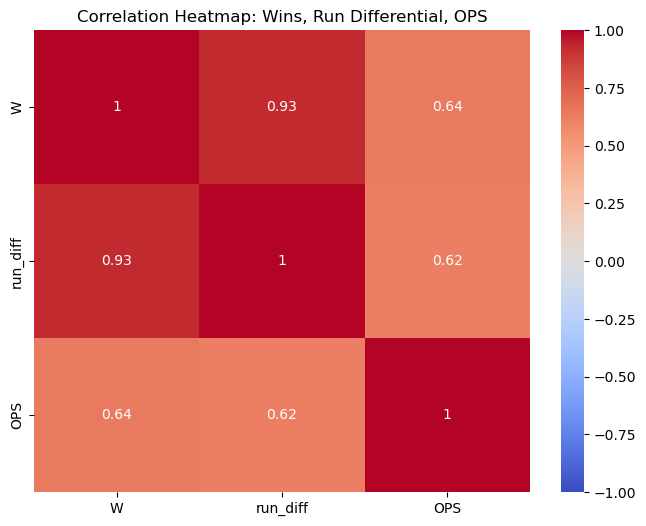

In [43]:
plt.figure(figsize=(8, 6))
corr_matrix = team_stats[["W", "run_diff", "OPS"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Wins, Run Differential, OPS")
plt.show()